In [1]:
import warnings
warnings.filterwarnings('ignore') # Отключаем варнинги RDKit для чистоты логов

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.warning')

# Наши кастомные модули
from etl_and_clean import DataLoader, DataCleaner
from feature_map import registry
from feature_builder import FeatureBuilder
from experiment_runner import ExperimentRunner
from analytics import DataAnalytics

# Машинное обучение
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.inspection import permutation_importance

In [2]:
# ==============================================================================
# ЯЧЕЙКА 2: ETL и Очистка (Выполняется один раз)
# ==============================================================================
# 1. Чтение и биологическая фильтрация
# Если данных много, для теста используй sample_size=500
df_raw = DataLoader.load_chembl_raw("chembl224.csv", sample_size=1_000_000)

# 2. Химическая топология и удаление шума
cleaner = DataCleaner(smiles_col='SMILES', target_col='Target', std_threshold=0.1)
df_clean = cleaner.process(df_raw)

Старт химической очистки...
-> Стандартизация графов и удаление солей...


100%|██████████| 3559/3559 [00:06<00:00, 585.09it/s]

-> Агрегация дубликатов по медиане и фильтрация шума...
   [!] Отброшено 78 молекул из-за противоречивых данных (std > 0.1).
Очистка завершена! Уникальных и надежных молекул: 2442


Анализ распределения целевой переменной 'Target'...


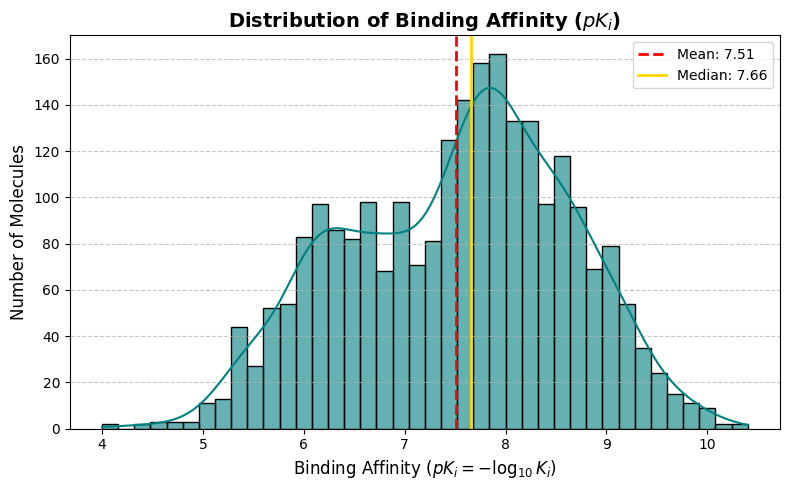

In [3]:
DataAnalytics.plot_target_distribution(df_clean, target_col='Target')

In [3]:
enricher = FeatureBuilder(registry)

# Запрашиваем "максимальный" набор всех возможных тегов, которые нам могут понадобиться
# all_candidate_features = ['lipinski', 'weber', '2d_physics', '3d_physics', '3d_quantum', 'fingerprints']
all_candidate_features = ['fingerprints', 'lipinski', 'weber', '2d_topology', 'charge_distribution', '3d_shape', '3d_physics']
# Считаем ВСЕ фичи. Это займет время, но только один раз.
df_enriched = enricher.enrich(df_clean, smiles_column='Clean_SMILES', requested_features=all_candidate_features)

Calculation started for 18 features: ['morgan_fp', 'mw', 'logp', 'hbd', 'hba', 'lipinski_violations', 'tpsa', 'delta_q', 'lambda_max', 'lambda_fiedler', 'wiener_index', 'fermi_energy', 'total_energy', 'coulomb_max', 'coulomb_trace', 'npr1', 'npr2', 'sasa']


  4%|▍         | 97/2442 [00:33<24:07,  1.62it/s]!!! Warning !!! Distance between atoms 48 and 10 (0.974826 A) is suspicious.
!!! Warning !!! Distance between atoms 60 and 19 (0.969119 A) is suspicious.
  8%|▊         | 200/2442 [01:05<02:30, 14.88it/s]!!! Warning !!! Distance between atoms 32 and 3 (0.979025 A) is suspicious.
!!! Warning !!! Distance between atoms 32 and 3 (0.980374 A) is suspicious.
  9%|▉         | 214/2442 [01:08<05:47,  6.41it/s]!!! Warning !!! Distance between atoms 33 and 11 (0.971041 A) is suspicious.
!!! Warning !!! Distance between atoms 38 and 18 (0.971042 A) is suspicious.
 13%|█▎        | 308/2442 [01:37<07:14,  4.92it/s]!!! Warning !!! Distance between atoms 45 and 20 (0.975202 A) is suspicious.
!!! Warning !!! Distance between atoms 47 and 22 (0.976353 A) is suspicious.
 14%|█▍        | 339/2442 [01:47<16:27,  2.13it/s]!!! Warning !!! Distance between atoms 44 and 18 (0.972853 A) is suspicious.
!!! Warning !!! Distance between atoms 45 and 19 (0.975014 A

In [4]:
df_enriched.head()

,Clean_SMILES,Target,morgan_fp,mw,logp,hbd,hba,lipinski_violations,tpsa,delta_q,lambda_max,lambda_fiedler,wiener_index,fermi_energy,total_energy,coulomb_max,coulomb_trace,npr1,npr2,sasa
0,Brc1ccc2c(c1)[C@H]1O[C@H](Cn3oc4ccc(-c5ccccc5)...,6.51,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",512.403,8.0835,0,3,2,36.53,0.638162,5.189700,0.025803,3510.0,-11.691805,-3041.238859,2563.819691,3893.206680,0.551374,0.700653,533.492929
1,Brc1ccc2c(c1)[C@H]1O[C@H](Cn3oc4ccc(CN5CCOCC5)...,6.72,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",535.438,6.2487,0,5,2,49.00,0.638139,5.175979,0.023140,3907.0,-11.691648,-3281.872120,2563.097389,3985.723977,0.225258,0.852128,573.807570
2,Brc1ccc2c(c1)[C@H]1O[C@H](Cn3oc4ccc(N5CCOCC5)c...,6.51,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",521.411,6.2531,0,5,2,49.00,0.638273,5.189700,0.025803,3510.0,-11.676340,-3175.244799,2561.384137,3947.865872,0.279402,0.944587,550.612844
3,Brc1ccnc2c1CCC1CNCCN21,5.41,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",268.158,1.5685,1,3,0,28.16,0.483490,5.194111,0.191875,326.0,-11.911755,-1432.747757,2558.580102,3111.928117,0.199094,0.841537,272.346876
4,Brc1ccnc2c1CC[C@@H]1CNCCCN21,5.86,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",282.185,1.9586,1,3,0,28.16,0.484673,5.188663,0.167655,390.0,-11.801185,-1539.308088,2558.875540,3149.786222,0.192868,0.847495,289.418686


In [23]:
FINAL_BASIS = enricher.select_orthogonal_basis(df_enriched, ['mw', 'logp', 'hbd', 'hba', 'tpsa',
                                                             'delta_q', 'lambda_max', 'lambda_fiedler', 'wiener_index',
                                                             'fermi_energy', 'total_energy', 'coulomb_max', 'coulomb_trace',
                                                             'npr1', 'npr2', 'sasa'])
print("Selected orthogonal basis features:", FINAL_BASIS)

Optimization of the basis (metrics: combined)...
Colinear featues dropped: 5. Resulted basis: 11 features.
Selected orthogonal basis features: ['logp', 'hbd', 'hba', 'tpsa', 'delta_q', 'lambda_max', 'lambda_fiedler', 'fermi_energy', 'coulomb_max', 'npr2', 'sasa']


Scanning features for multicollinearity...


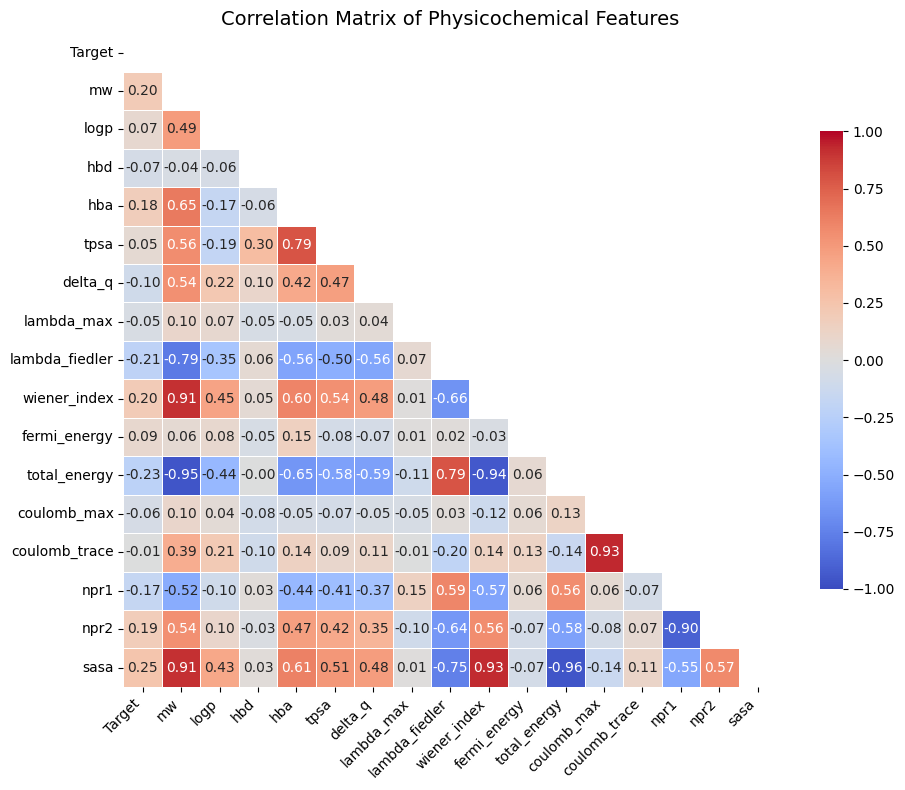

,Target,mw,logp,hbd,hba,tpsa,delta_q,lambda_max,lambda_fiedler,wiener_index,fermi_energy,total_energy,coulomb_max,coulomb_trace,npr1,npr2,sasa
Target,1.000000,0.202493,0.071070,-0.068631,0.176641,0.054745,-0.099191,-0.046200,-0.211989,0.196641,0.085699,-0.225981,-0.056979,-0.006503,-0.169579,0.186670,0.245275
mw,0.202493,1.000000,0.491070,-0.043844,0.647463,0.557823,0.544811,0.096767,-0.786033,0.908323,0.055521,-0.953706,0.100978,0.391491,-0.518567,0.540496,0.906635
logp,0.071070,0.491070,1.000000,-0.056869,-0.166088,-0.186128,0.219859,0.072087,-0.349162,0.450498,0.078464,-0.438596,0.043979,0.205575,-0.101464,0.099634,0.427347
hbd,-0.068631,-0.043844,-0.056869,1.000000,-0.060638,0.298112,0.098450,-0.051414,0.058044,0.051509,-0.047565,-0.001904,-0.084581,-0.100121,0.026808,-0.026842,0.029444
hba,0.176641,0.647463,-0.166088,-0.060638,1.000000,0.790130,0.417277,-0.048998,-0.563178,0.599208,0.153275,-0.645197,-0.054703,0.142058,-0.441733,0.470857,0.613892
tpsa,0.054745,0.557823,-0.186128,0.298112,0.790130,1.000000,0.470831,0.026172,-0.500778,0.540946,-0.076967,-0.582960,-0.074825,0.089361,-0.405379,0.416115,0.514799
delta_q,-0.099191,0.544811,0.219859,0.098450,0.417277,0.470831,1.000000,0.042157,-0.560750,0.476842,-0.065252,-0.592134,-0.053786,0.105495,-0.365767,0.345304,0.482459
lambda_max,-0.046200,0.096767,0.072087,-0.051414,-0.048998,0.026172,0.042157,1.000000,0.065602,0.009203,0.010944,-0.108393,-0.054687,-0.007622,0.147153,-0.097682,0.014790
lambda_fiedler,-0.211989,-0.786033,-0.349162,0.058044,-0.563178,-0.500778,-0.560750,0.065602,1.000000,-0.662985,0.015659,0.790169,0.027293,-0.197673,0.587197,-0.635756,-0.754664
wiener_index,0.196641,0.908323,0.450498,0.051509,0.599208,0.540946,0.476842,0.009203,-0.662985,1.000000,-0.034860,-0.941204,-0.121344,0.135632,-0.566170,0.558221,0.929320


In [24]:
DataAnalytics.check_correlations(df_enriched, ['Target', 'mw', 'logp', 'hbd', 'hba', 'tpsa',
                                                             'delta_q', 'lambda_max', 'lambda_fiedler', 'wiener_index',
                                                             'fermi_energy', 'total_energy', 'coulomb_max', 'coulomb_trace',
                                                             'npr1', 'npr2', 'sasa'], plot=True)

In [25]:
# FINAL_BASIS.append('morgan_fp')
# FINAL_BASIS = ['morgan_fp']
print(FINAL_BASIS)
x, y, features = enricher.get_tensors(df_enriched, FINAL_BASIS, 'Target')

['logp', 'hbd', 'hba', 'tpsa', 'delta_q', 'lambda_max', 'lambda_fiedler', 'fermi_energy', 'coulomb_max', 'npr2', 'sasa']
Found 22 missed values (NaN). Replaced with 0.0.
Matrix X collected. Dimensions: (2442, 11)


Launch 5-Fold CV for RandomForestRegressor...
Experiment finished.

Metrics Random Forest:
R2_mean:	0.5793
R2_std:	0.0241
RMSE_mean:	0.7208
RMSE_std:	0.0273
MAE_mean:	0.5272
MAE_std:	0.0169
Time_seconds:	2.7999


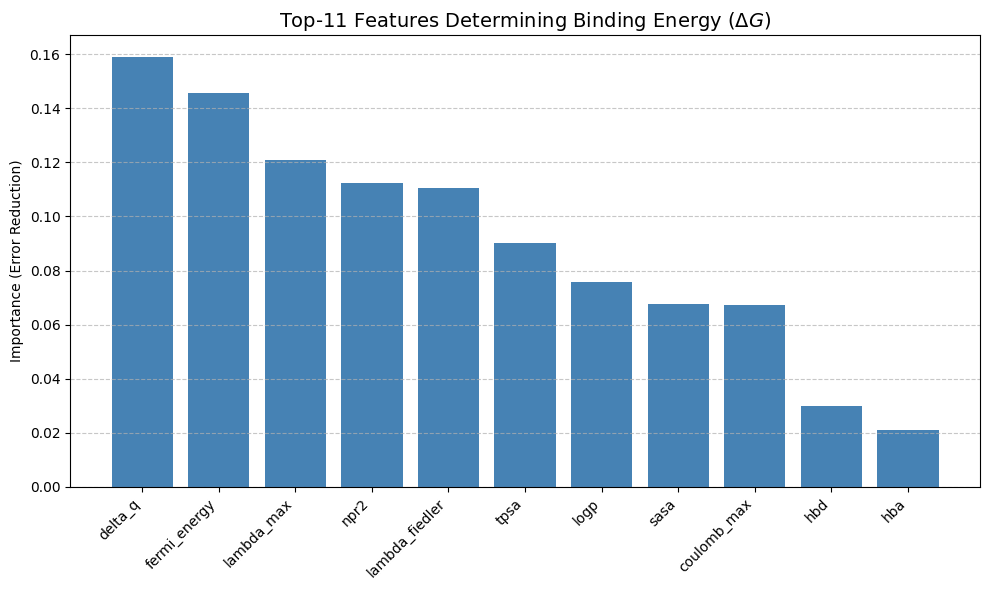

Calculating SHAP values (analyzing physical contributions)...


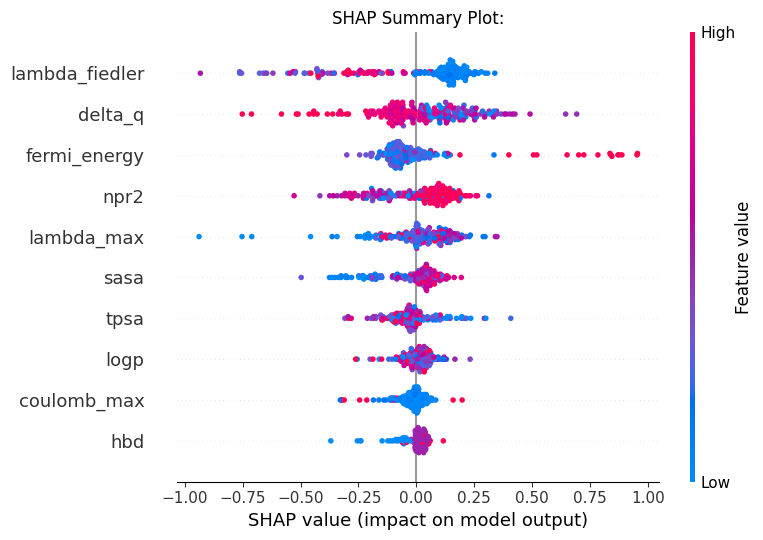

In [29]:
rf_model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
runner_rf = ExperimentRunner(model=rf_model)
runner_rf.run(x, y, features)

print("Metrics Random Forest:")
for k, v in runner_rf.get_metrics().items():
    print(f"{k}:\t{v:.4f}")

# Отрисовка важности
DataAnalytics.plot_feature_importance(runner_rf.get_model(), runner_rf.feature_names, 11)
DataAnalytics.plot_shap_analysis(runner_rf.get_model(), x, runner_rf.feature_names, sample_size=200)

Launch 5-Fold CV for CatBoostRegressor...
Experiment finished.

Metrics CatBoost:
R2_mean:	0.5819
R2_std:	0.0274
RMSE_mean:	0.7187
RMSE_std:	0.0333
MAE_mean:	0.5358
MAE_std:	0.0214
Time_seconds:	8.0552


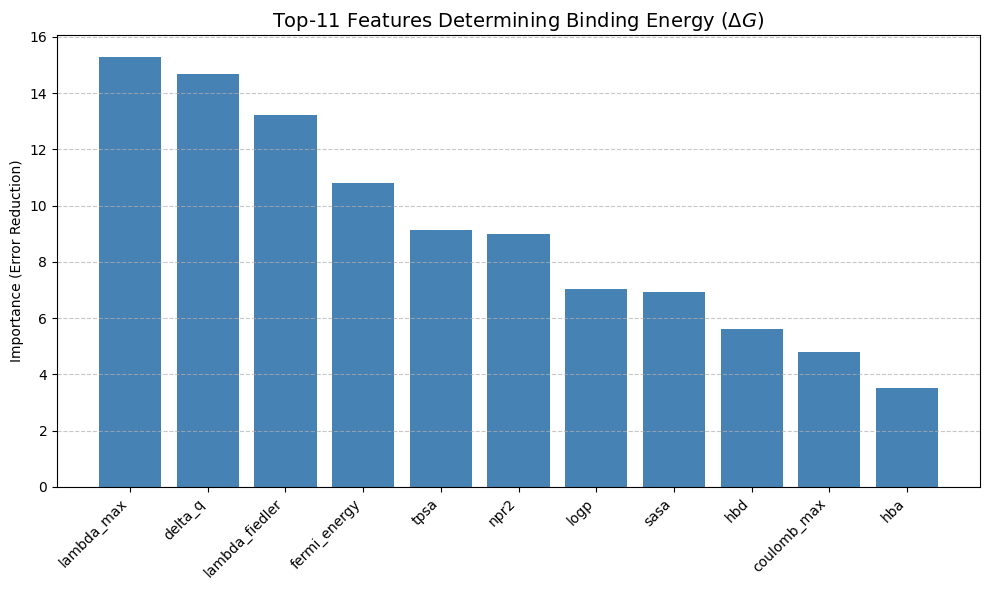

Calculating SHAP values (analyzing physical contributions)...


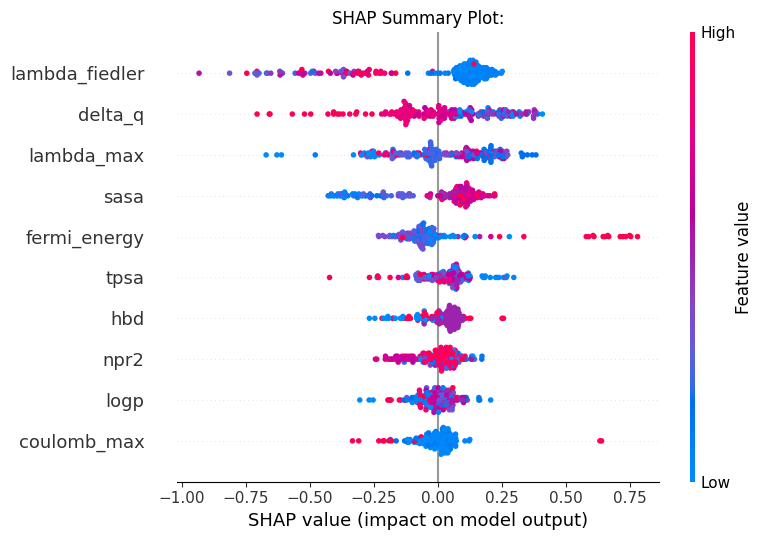

In [30]:
cat_model = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_seed=42)
runner_cat = ExperimentRunner(model=cat_model)
runner_cat.run(x, y, features)

print("Metrics CatBoost:")
for k, v in runner_cat.get_metrics().items():
    print(f"{k}:\t{v:.4f}")

# Отрисовка важности
DataAnalytics.plot_feature_importance(runner_cat.get_model(), runner_cat.feature_names, 11)
DataAnalytics.plot_shap_analysis(runner_cat.get_model(), x, runner_cat.feature_names, sample_size=200)

Launch 5-Fold CV for LGBMRegressor...
Experiment finished.

Metrics LGBM:
R2_mean:	0.5938
R2_std:	0.0275
RMSE_mean:	0.7082
RMSE_std:	0.0302
MAE_mean:	0.5217
MAE_std:	0.0192
Time_seconds:	5.6847


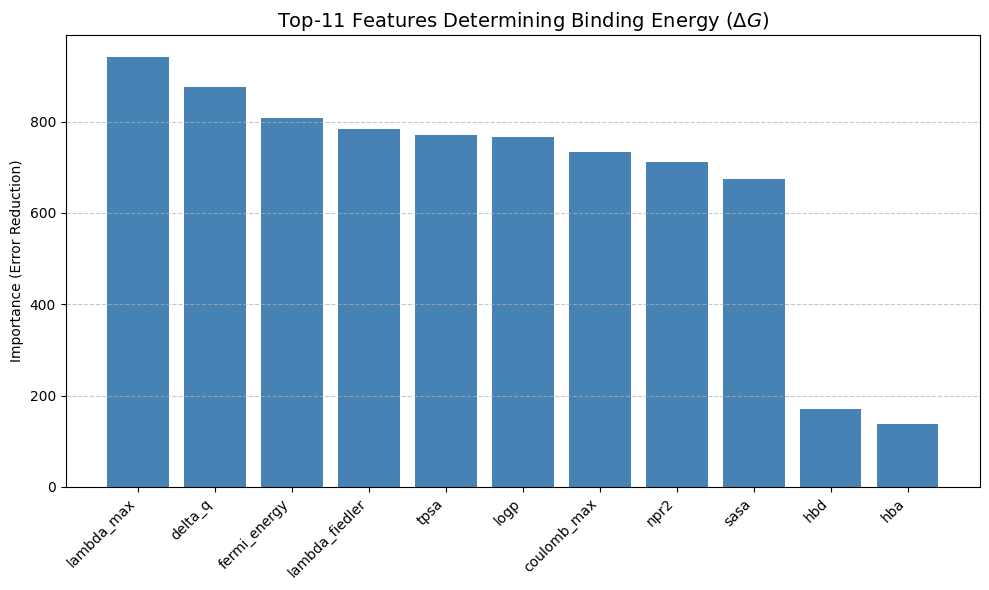

Calculating SHAP values (analyzing physical contributions)...


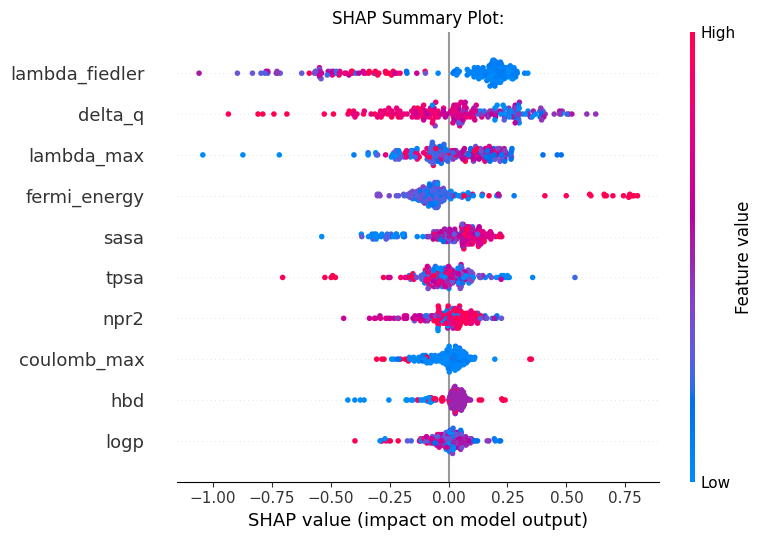

In [31]:
lgbm_model = LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=8, verbose=-1, random_state=42, n_jobs=-1)
runner_lgbm = ExperimentRunner(model=lgbm_model)
runner_lgbm.run(x, y, features)

print("Metrics LGBM:")
for k, v in runner_lgbm.get_metrics().items():
    print(f"{k}:\t{v:.4f}")

# Отрисовка важности
DataAnalytics.plot_feature_importance(runner_lgbm.get_model(), runner_lgbm.feature_names, 11)
DataAnalytics.plot_shap_analysis(runner_lgbm.get_model(), x, runner_lgbm.feature_names, sample_size=200)

Launch 5-Fold CV for XGBRegressor...
Experiment finished.

Metrics XGBoost:
R2_mean:	0.6099
R2_std:	0.0190
RMSE_mean:	0.6942
RMSE_std:	0.0232
MAE_mean:	0.5097
MAE_std:	0.0137
Time_seconds:	8.3097


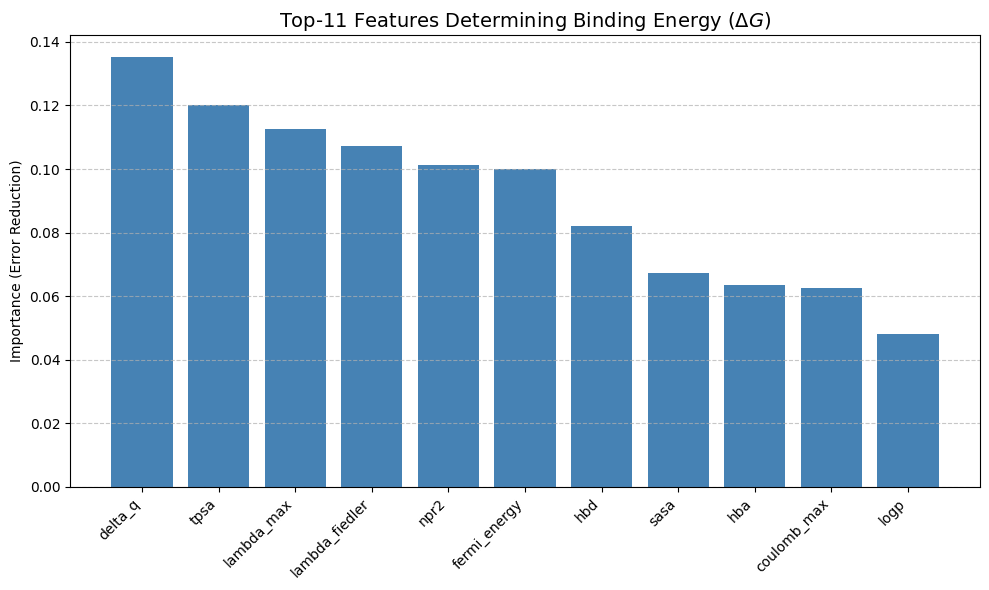

Calculating SHAP values (analyzing physical contributions)...


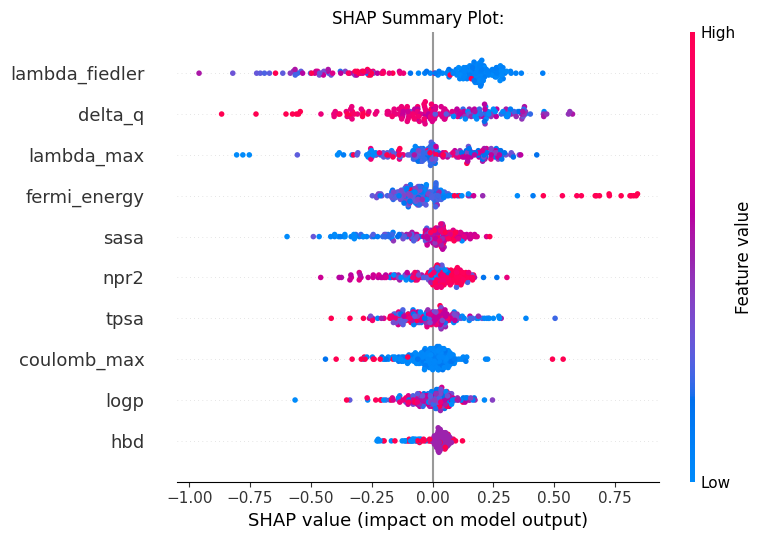

In [32]:
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, random_state=42, n_jobs=-1)

runner_xgb = ExperimentRunner(model=xgb_model)
runner_xgb.run(x, y, features)

print("Metrics XGBoost:")
for k, v in runner_xgb.get_metrics().items():
    print(f"{k}:\t{v:.4f}")

# Отрисовка важности
DataAnalytics.plot_feature_importance(runner_xgb.get_model(), runner_xgb.feature_names, 11)
DataAnalytics.plot_shap_analysis(runner_xgb.get_model(), x, runner_xgb.feature_names, sample_size=200)

In [33]:
# ==========================================
# 1. Интеллектуальное разделение колонок
# ==========================================
# Находим ИНДЕКСЫ колонок Моргана и колонок физики в списке feature_names
morgan_indices = [i for i, name in enumerate(features) if name.startswith('morgan_bit_')]
physics_indices = [i for i, name in enumerate(features) if not name.startswith('morgan_bit_')]

print(f"Найдено бит Моргана: {len(morgan_indices)}")
print(f"Найдено физических дескрипторов: {len(physics_indices)}")

# ==========================================
# 2. Сборка Препроцессора
# ==========================================
preprocessor = ColumnTransformer(
    transformers=[
        # Применяем StandardScaler ТОЛЬКО к колонкам с физикой
        ('physics_scaler', StandardScaler(), physics_indices),
        # Колонки Моргана пропускаем без изменений
        ('morgan_passthrough', 'passthrough', morgan_indices)
    ]
)

# ==========================================
# 3. Сборка Пайплайна
# ==========================================
# C=10.0 и epsilon=0.1 - это классические хорошие дефолты для SVR в хемоинформатике
svr_pipeline = Pipeline([
    ('scaler', preprocessor),
    ('svr', SVR(kernel='rbf', C=10.0, gamma='scale', epsilon=0.1))
])

# ==========================================
# 4. Запуск эксперимента
# ==========================================
print("\n>>> ЗАПУСК EXPERIMENT: Support Vector Regressor (SVR) <<<")
runner_svr = ExperimentRunner(model=svr_pipeline)

# Отдаем пайплайн нашему "голому" раннеру
runner_svr.run(x, y, features, n_splits=5, random_state=42)

print("\nМетрики SVR:")
for k, v in runner_svr.get_metrics().items():
    print(f"{k}:\t{v:.4f}")


Найдено бит Моргана: 0
Найдено физических дескрипторов: 11

>>> ЗАПУСК EXPERIMENT: Support Vector Regressor (SVR) <<<
Launch 5-Fold CV for Pipeline...
Experiment finished.


Метрики SVR:
R2_mean:	0.5067
R2_std:	0.0315
RMSE_mean:	0.7804
RMSE_std:	0.0301
MAE_mean:	0.5753
MAE_std:	0.0209
Time_seconds:	4.8021


Scanning the dataset for the presence of bit 810...
Fragment found! Displaying the 2D structure...


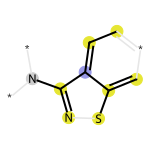

In [ ]:
DataAnalytics.draw_morgan_bit(df_enriched, target_bit=810)